=== CEK MISSING VALUE ===
Total Missing Value: 0

=== STATISTIK DESKRIPTIF ===
               age       charges
count  1338.000000   1338.000000
mean     39.207025  13270.422265
std      14.049960  12110.011237
min      18.000000   1121.873900
25%      27.000000   4740.287150
50%      39.000000   9382.033000
75%      51.000000  16639.912515
max      64.000000  63770.428010

=== DETEKSI OUTLIER (IQR & Z-score) ===

Analisis outlier untuk variabel: age
  - Outlier (IQR): 0
  - Outlier (Z-score > 3): 0
  - Batas bawah: -9.0
  - Batas atas: 87.0

Analisis outlier untuk variabel: charges
  - Outlier (IQR): 139
  - Outlier (Z-score > 3): 7
  - Batas bawah: -13109.15
  - Batas atas: 34489.35



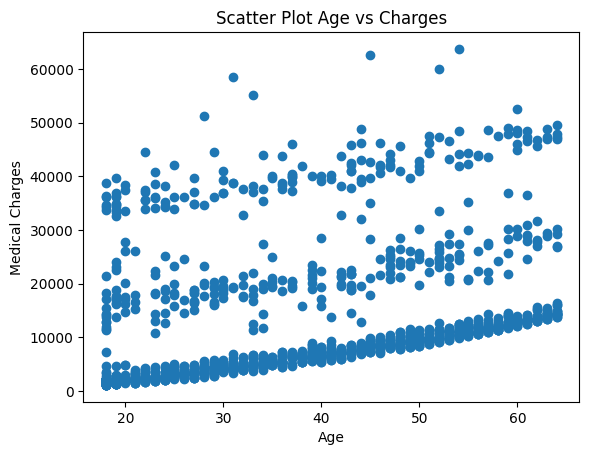


=== KORELASI ===
Korelasi Pearson: 0.299
p-value: 0.0

=== RINGKASAN MODEL REGRESI ===
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     131.2
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           4.89e-29
Time:                        16:00:48   Log-Likelihood:                -14415.
No. Observations:                1338   AIC:                         2.883e+04
Df Residuals:                    1336   BIC:                         2.884e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

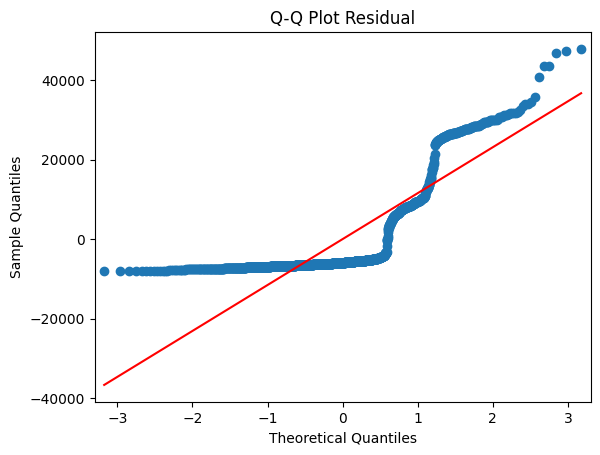


2. Breusch-Pagan
Statistik LM = 0.0004
p-value = 0.983776


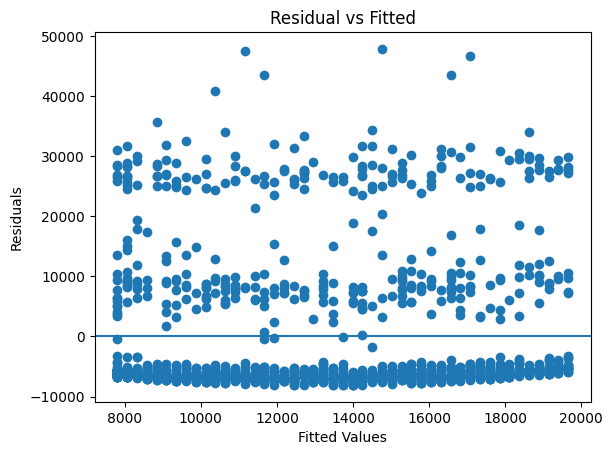

In [26]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson


df = pd.read_csv("/content/insurance.csv")
data = df[["age", "charges"]]

# 1. CEK MISSING VALUE
print("=== CEK MISSING VALUE ===")
print("Total Missing Value:", data.isna().sum().sum())


# 2. STATISTIK DESKRIPTIF
print("\n=== STATISTIK DESKRIPTIF ===")
print(data.describe())

# 3. DETEKSI OUTLIER
def detect_outliers(data):
    print("\n=== DETEKSI OUTLIER (IQR & Z-score) ===\n")
    for col in data.columns:
        print(f"Analisis outlier untuk variabel: {col}")
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_iqr = data[(data[col] < lower_bound) |
                            (data[col] > upper_bound)][col]
        z_scores = np.abs(stats.zscore(data[col]))
        outliers_z = data[col][z_scores > 3]

        print("  - Outlier (IQR):", len(outliers_iqr))
        print("  - Outlier (Z-score > 3):", len(outliers_z))
        print("  - Batas bawah:", round(lower_bound,2))
        print("  - Batas atas:", round(upper_bound,2))
        print()

detect_outliers(data)


# 4. VISUALISASI AWAL
plt.figure()
plt.scatter(data["age"], data["charges"])
plt.xlabel("Age")
plt.ylabel("Medical Charges")
plt.title("Scatter Plot Age vs Charges")
plt.show()

# 5. KORELASI
corr, p_corr = stats.pearsonr(data["age"], data["charges"])
print("\n=== KORELASI ===")
print("Korelasi Pearson:", round(corr,4))
print("p-value:", round(p_corr,6))

# 6. REGRESI LINEAR
X = sm.add_constant(data["age"])
y = data["charges"]
model = sm.OLS(y, X).fit()

print("\n=== RINGKASAN MODEL REGRESI ===")
print(model.summary())

# 7. UJI HIPOTESIS
alpha = 0.05
p_value = model.pvalues["age"]

print("\n=== UJI HIPOTESIS ===")
print("H0 : β1 = 0 (age tidak berpengaruh terhadap charges)")
print("H1 : β1 ≠ 0 (age berpengaruh terhadap charges)")
print("p-value:", p_value)

if p_value < alpha:
    print("Keputusan: Tolak H0")
else:
    print("Keputusan: Gagal Tolak H0")

# 8. UJI ASUMSI REGRESI
print("\n=== UJI ASUMSI REGRESI ===")

# Normalitas Residual
shapiro = stats.shapiro(model.resid)
print("\n1. Shapiro-Wilk")
print("Statistik W =", round(shapiro.statistic,4))
print("p-value =", round(shapiro.pvalue,6))

# Q-Q Plot
sm.qqplot(model.resid, line='s')
plt.title("Q-Q Plot Residual")
plt.show()

# Homoskedastisitas
bp = het_breuschpagan(model.resid, model.model.exog)
print("\n2. Breusch-Pagan")
print("Statistik LM =", round(bp[0],4))
print("p-value =", round(bp[1],6))

# Plot Residual vs Fitted
plt.figure()
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(y=0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted")
plt.show()